In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
import os, torch, time, json

out = {
    "torch_version": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "visible_devices": torch.cuda.device_count(),
}

if out["cuda_available"] and out["visible_devices"] > 0:
    out["device_name"] = torch.cuda.get_device_name(0)

    # 간단한 GPU 연산 테스트 (행렬 곱 + 동기화로 실제 계산 강제)
    t0 = time.time()
    x = torch.randn(4096, 4096, device="cuda")
    y = x @ x
    torch.cuda.synchronize()
    out["matmul"] = {"shape": list(y.shape), "device": str(y.device), "ms": round((time.time()-t0)*1000, 1)}

    # 메모리 정보
    try:
        free, total = torch.cuda.mem_get_info()
        out["cuda_mem_GB"] = {"free": round(free/1e9, 2), "total": round(total/1e9, 2)}
    except Exception as e:
        out["cuda_mem_info_error"] = str(e)
else:
    out["note"] = "CUDA 미사용 상태입니다. (GPU Limit=1 설정/스케줄 여부 확인)"

print(json.dumps(out, indent=2, ensure_ascii=False))


{
  "torch_version": "2.7.1+cu118",
  "cuda_runtime": "11.8",
  "cuda_available": true,
  "visible_devices": 1,
  "device_name": "NVIDIA GeForce RTX 3080 Ti Laptop GPU",
  "matmul": {
    "shape": [
      4096,
      4096
    ],
    "device": "cuda:0",
    "ms": 6476.1
  },
  "cuda_mem_GB": {
    "free": 14.88,
    "total": 17.18
  }
}


In [15]:
import os, torch, time, json

out = {
    "torch_version": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "visible_devices": torch.cuda.device_count(),
}

if out["cuda_available"] and out["visible_devices"] > 0:
    out["device_name"] = torch.cuda.get_device_name(0)

    # 간단한 GPU 연산 테스트 (행렬 곱 + 동기화로 실제 계산 강제)
    t0 = time.time()
    x = torch.randn(4096, 4096, device="cuda")
    y = x @ x
    torch.cuda.synchronize()
    out["matmul"] = {"shape": list(y.shape), "device": str(y.device), "ms": round((time.time()-t0)*1000, 1)}

    # 메모리 정보
    try:
        free, total = torch.cuda.mem_get_info()
        out["cuda_mem_GB"] = {"free": round(free/1e9, 2), "total": round(total/1e9, 2)}
    except Exception as e:
        out["cuda_mem_info_error"] = str(e)
else:
    out["note"] = "CUDA 미사용 상태입니다. (GPU Limit=1 설정/스케줄 여부 확인)"

print(json.dumps(out, indent=2, ensure_ascii=False))


{
  "torch_version": "2.7.1+cu118",
  "cuda_runtime": "11.8",
  "cuda_available": true,
  "visible_devices": 1,
  "device_name": "NVIDIA GeForce RTX 3080 Ti Laptop GPU",
  "matmul": {
    "shape": [
      4096,
      4096
    ],
    "device": "cuda:0",
    "ms": 72.9
  },
  "cuda_mem_GB": {
    "free": 14.81,
    "total": 17.18
  }
}


In [25]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, SimpleRNN, LSTM, GRU, BatchNormalization, Flatten
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error

In [17]:
from keras.datasets import fashion_mnist
(x_data, y_data), (tt_x, tt_y) = fashion_mnist.load_data()
tr_x, val_x, tr_y, val_y = train_test_split(x_data, y_data, test_size=.2)
tr_x.shape, val_x.shape, tt_x.shape, tr_y.shape, val_y.shape, tt_y.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((48000, 28, 28),
 (12000, 28, 28),
 (10000, 28, 28),
 (48000,),
 (12000,),
 (10000,))

In [18]:
s_tr_x = tr_x/255
s_tt_x = tt_x/255
s_val_x = val_x/255

In [ ]:
tr_y # to categorical을 쓰는 것이 좋으나 메모리 측면에서 그냥 사용하는 것이 좋음

array([8, 2, 6, ..., 9, 5, 2], dtype=uint8)

In [ ]:
e_tr_x = s_tr_x.reshape(-1, 28, 28, 1) # 각 데이터의 크기 및 채널 등은 정해지지만 데이터 개수는 정해지지 않음
e_tt_x = s_tt_x.reshape(-1, 28, 28, 1)
e_val_x = s_val_x.reshape(-1, 28, 28, 1)
e_tr_x.shape, e_tt_x.shape, e_val_x.shape

((48000, 28, 28, 1), (10000, 28, 28, 1), (12000, 28, 28, 1))

In [22]:
# e_tr_y = tr_y.reshape(-1,1)
# e_tr_x.shape, e_tr_y.shape # shape에서 48000, 으로 끝나면 1. 없는 경우, 2. 정의할 수 없는 경우인데
#                             # 없으면 지도 학습이 될 수 없음
#                             # 정의할 수 없는 경우는 ...

((48000, 28, 28, 1), (48000, 1))

In [50]:
from keras.utils import to_categorical # 원핫인코더는 아니고 함수일 뿐임
e_tr_y = to_categorical(tr_y) # 딥러닝 파트에선 권장되지 않음 => 딥러닝은 메모리를 많이 쓰기 때문임
e_tt_y = to_categorical(tt_y)
e_val_y = to_categorical(val_y)
e_tr_x.shape, e_tr_y.shape

((48000, 28, 28, 1), (48000, 10))

In [46]:
# 모델(CNN) # 통상적으로 CNN은 크기는 줄어들되 채널은 늘어나도록 하는 것이 권장사항임
m = Sequential()
m.add(Input(shape=(e_tr_x.shape[1:]))) # 28,28,1
m.add(Conv2D(32, 3, 1, padding='same', activation='relu')) # 28,28,32
m.add(MaxPooling2D(2)) # 14,14,32
m.add(Conv2D(64, 3, 1, padding='same', activation='relu')) # 14,14,64
m.add(MaxPooling2D(2)) # 7,7,64
m.add(Conv2D(128, 3, 1, padding='same', activation='relu')) # 7,7,128
m.add(MaxPooling2D(2)) # 3,3,128 # 소수점은 내림 적용
m.add(Conv2D(256, 3, 1, padding='same', activation='relu')) # 7,7,128
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100,activation='relu'))
m.add(Dense(10,activation='softmax'))
m.summary() # 크기가 아무리 작아져도 '이미지'라는 특성을 갖고 있으므로 벡터로 바꿔야함

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,550 (1.58 MB)

 Trainable params: 414,550 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 위 내용에서 빠진 것은? => softmax, 평탄화
# 왜 CNN은 마지막에 FC레이어를 사용할까? => 출력항목을 결정짓는 특징을 모두 확인해야 하기 때문임
# 초기가중치는 설정되어 있음

# 임의의 테스트

In [29]:
m.predict(e_tr_x).shape

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step


(48000, 10)

In [30]:
py = m.predict(e_tr_x)
ty = e_tr_y

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step


In [32]:
np.argmax(py, axis=1)

array([4, 4, 4, ..., 4, 4, 4])

In [33]:
np.argmax(ty, axis=1)

array([8, 2, 6, ..., 9, 5, 2])

In [41]:
classification_report(np.argmax(py, axis=1), np.argmax(ty, axis=1))

c:\Users\devchoi\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\devchoi\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\devchoi\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


'              precision    recall  f1-score   support\n\n           0       0.00      0.07      0.00       100\n           1       0.00      0.00      0.00         0\n           2       0.00      0.00      0.00        37\n           3       0.00      0.00      0.00         0\n           4       0.86      0.11      0.19     38076\n           5       0.53      0.26      0.35      9780\n           6       0.00      0.00      0.00         6\n           7       0.00      0.00      0.00         0\n           8       0.00      0.00      0.00         0\n           9       0.00      0.00      0.00         1\n\n    accuracy                           0.14     48000\n   macro avg       0.14      0.04      0.05     48000\nweighted avg       0.79      0.14      0.23     48000\n'

In [47]:
m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc']) # 분류한다면 acc는 항상 넣는 걸로 하자

In [ ]:
# 사실은 직접 시각적으로 학습과정을 확인해야 하므로 과정을 시각화하는 callback함수도 만들 수 있어야 함
es = EarlyStopping(patience=5, restore_best_weights=True)
ck = ModelCheckpoint(save_best_only=True)

In [48]:
hy = m.fit(e_tr_x, e_tr_y, epochs=7, validation_split=0.2) # 이미지 데이터를 도출하기 때문에 

Epoch 1/7
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - acc: 0.8120 - loss: 0.5099 - val_acc: 0.8637 - val_loss: 0.3789
Epoch 2/7
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - acc: 0.8874 - loss: 0.3101 - val_acc: 0.8950 - val_loss: 0.2895
Epoch 3/7
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - acc: 0.9055 - loss: 0.2574 - val_acc: 0.9097 - val_loss: 0.2527
Epoch 4/7
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - acc: 0.9168 - loss: 0.2246 - val_acc: 0.9165 - val_loss: 0.2343
Epoch 5/7
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - acc: 0.9281 - loss: 0.1942 - val_acc: 0.9165 - val_loss: 0.2330
Epoch 6/7
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - acc: 0.9359 - loss: 0.1693 - val_acc: 0.9083 - val_loss: 0.2549
Epoch 7/7
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - acc: 0.9447 - loss: 0.1480 - val_acc: 0.9147 - val_loss: 0.2492


### 일반화의 오류를 낮춰야함

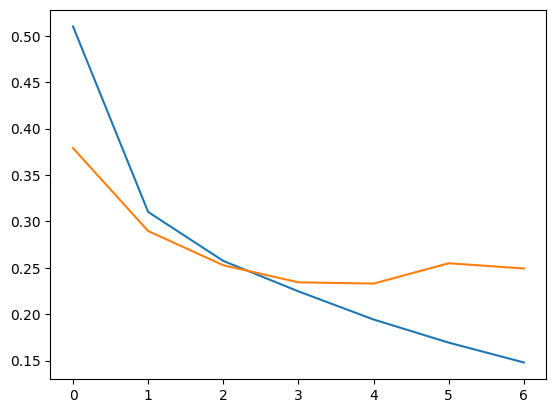

In [49]:
import matplotlib.pyplot as plt
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

In [52]:
tr_scs = m.evaluate(e_tr_x, e_tr_y)
val_scs = m.evaluate(e_val_x, e_val_y)
tt_scs = m.evaluate(e_tt_x, e_tt_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.9475 - loss: 0.1431
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9120 - loss: 0.2595
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9069 - loss: 0.2786


In [ ]:
all_acc = np.abs(tr_scs[1]-val_scs[1]) + np.abs(tr_scs[1]-tt_scs[1]) + np.abs(tt_scs[1]-val_scs[1])
all_acc # 일반화 오차의 총합 (accuracy관점)

np.float64(0.0811166763305664)

In [56]:
all_loss = np.abs(tr_scs[0]-val_scs[0]) + np.abs(tr_scs[0]-tt_scs[0]) + np.abs(tt_scs[0]-val_scs[0])
all_loss

np.float64(0.2710091471672058)